Using ANN

In [ ]:
#imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
#load dataset
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
#check shape
print(X_train.shape)

print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [ ]:
#normalize
X_train=X_train/255.0

X_test=X_test/255.0

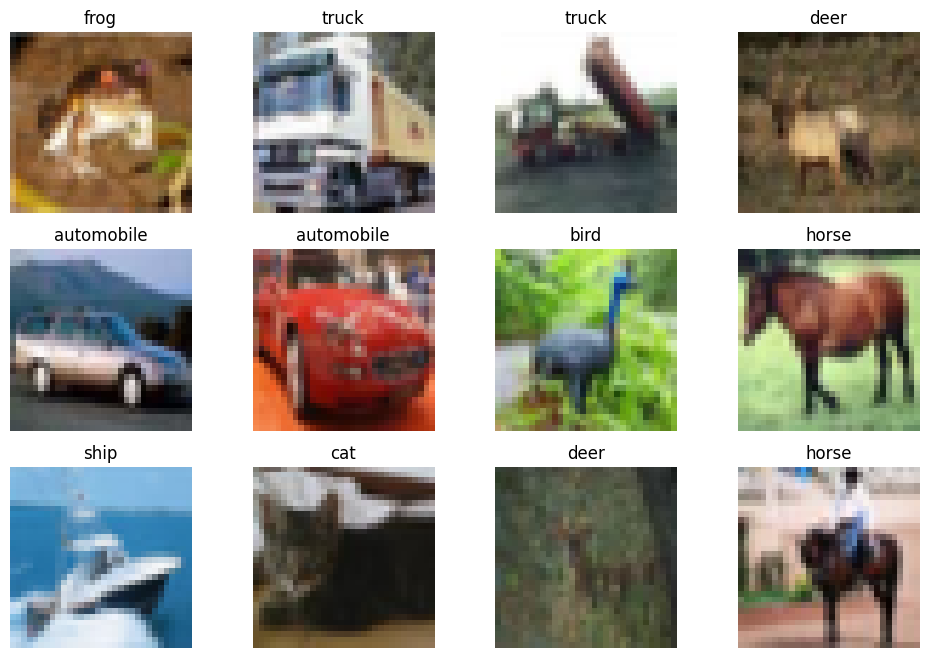

In [ ]:
#visualize images
classes=[
'airplane',
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck'
]

plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_train[i])

    plt.title(classes[y_train[i][0]])

    plt.axis('off')

plt.show()

In [ ]:
#ANN architecture
ann=Sequential()

ann.add(Flatten(input_shape=(32,32,3)))

ann.add(Dense(512,activation='relu'))

ann.add(Dropout(0.3))

ann.add(Dense(256,activation='relu'))

ann.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#compile
ann.compile(

optimizer='adam',

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)

In [ ]:
#train
history_ann=ann.fit(

X_train,

y_train,

epochs=20,

batch_size=64,

validation_split=0.2

)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.2616 - loss: 2.0188 - val_accuracy: 0.3149 - val_loss: 1.8610
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.3154 - loss: 1.8742 - val_accuracy: 0.3482 - val_loss: 1.8048
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.3313 - loss: 1.8287 - val_accuracy: 0.3600 - val_loss: 1.7731
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.3514 - loss: 1.7953 - val_accuracy: 0.3786 - val_loss: 1.7435
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3564 - loss: 1.7730 - val_accuracy: 0.4008 - val_loss: 1.7163
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3670 - loss: 1.7457 - val_accuracy: 0.4040 - val_loss: 1.7024
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3713 - loss: 1.7345 - val_accuracy: 0.4063 - val_loss: 1.7135
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.3756 - loss: 1.7176 - 

In [ ]:
#evaluate
ann.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4418 - loss: 1.5923


[1.5922913551330566, 0.44179999828338623]

Complete Standard Pipeline of CNN

In [ ]:
#imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

In [ ]:
#Configuration
# Hyperparameters

IMAGE_SIZE=(32,32)

BATCH_SIZE=64

EPOCHS=10

LEARNING_RATE=0.001

NUM_CLASSES=10

MODEL_PATH='best_cnn_model.keras'

In [ ]:
#load dataset
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [ ]:
#normalize
X_train=X_train.astype('float32')/255

X_test=X_test.astype('float32')/255

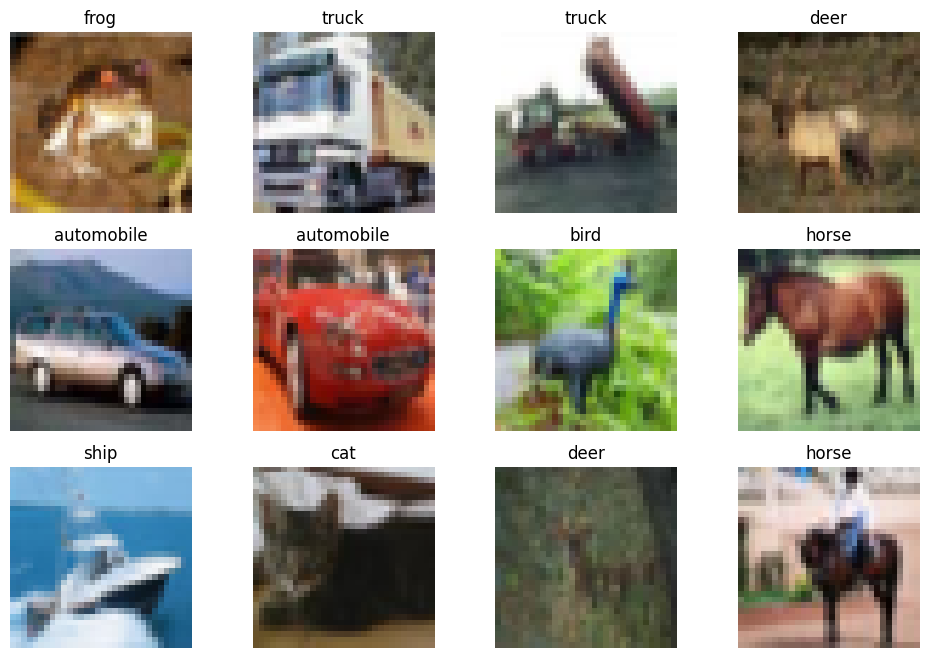

In [ ]:
#visualize dataset
classes=[

'airplane',

'automobile',

'bird',

'cat',

'deer',

'dog',

'frog',

'horse',

'ship',

'truck'

]


plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_train[i])

    plt.title(classes[y_train[i][0]])

    plt.axis('off')


plt.show()

In [ ]:
#data augmentation
train_datagen=ImageDataGenerator(

rotation_range=15,

width_shift_range=0.1,

height_shift_range=0.1,

horizontal_flip=True,

zoom_range=0.1

)


train_datagen.fit(X_train)

In [ ]:
#CNN model
model=Sequential()


# Block 1

model.add(

Conv2D(

filters=32,

kernel_size=(3,3),

padding='same',

activation='relu',

input_shape=(32,32,3)

)

)

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))


# Block 2

model.add(

Conv2D(

filters=64,

kernel_size=(3,3),

padding='same',

activation='relu'

)

)

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))


# Block 3

model.add(

Conv2D(

filters=128,

kernel_size=(3,3),

padding='same',

activation='relu'

)

)

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.3))


# Dense Layers

model.add(Flatten())

model.add(

Dense(

256,

activation='relu'

)

)

model.add(

Dropout(

0.5

)

)

model.add(

Dense(

10,

activation='softmax'

)

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Complie Model
model.compile(

optimizer=Adam(

learning_rate=LEARNING_RATE

),

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)

In [ ]:
#model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Callbacks
early_stop=EarlyStopping(

monitor='val_loss',

patience=10,

restore_best_weights=True

)


checkpoint=ModelCheckpoint(

filepath=MODEL_PATH,

monitor='val_accuracy',

save_best_only=True,

verbose=1

)


reduce_lr=ReduceLROnPlateau(

monitor='val_loss',

factor=0.1,

patience=5,

verbose=1

)

In [ ]:
#train model
history=model.fit(

train_datagen.flow(

X_train,

y_train,

batch_size=BATCH_SIZE

),

epochs=EPOCHS,

validation_data=(X_test,y_test),

callbacks=[

early_stop,

checkpoint,

reduce_lr

]

)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.4311 - loss: 1.5633
Epoch 1: val_accuracy improved from None to 0.49650, saving model to best_cnn_model.keras

Epoch 1: finished saving model to best_cnn_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 186s 238ms/step - accuracy: 0.4429 - loss: 1.5289 - val_accuracy: 0.4965 - val_loss: 1.5022 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.4914 - loss: 1.4153
Epoch 2: val_accuracy improved from 0.49650 to 0.60620, saving model to best_cnn_model.keras

Epoch 2: finished saving model to best_cnn_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 234ms/step - accuracy: 0.5033 - loss: 1.3881 - val_accuracy: 0.6062 - val_loss: 1.1529 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.5362 - loss: 1.3064
Epoch 3: val_accuracy did not improve from 0.60620
782/782 ━━━━━━━━━━━━━━━━━━━━ 183s 234ms/step - accuracy: 0.5410 - loss: 1.2938 - val_accuracy: 0.586

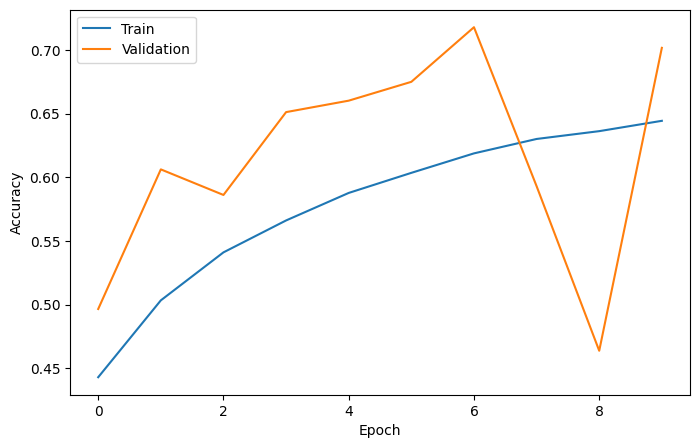

In [ ]:
#plot accuracy
plt.figure(figsize=(8,5))

plt.plot(

history.history['accuracy']

)

plt.plot(

history.history['val_accuracy']

)

plt.legend(

['Train','Validation']

)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.show()

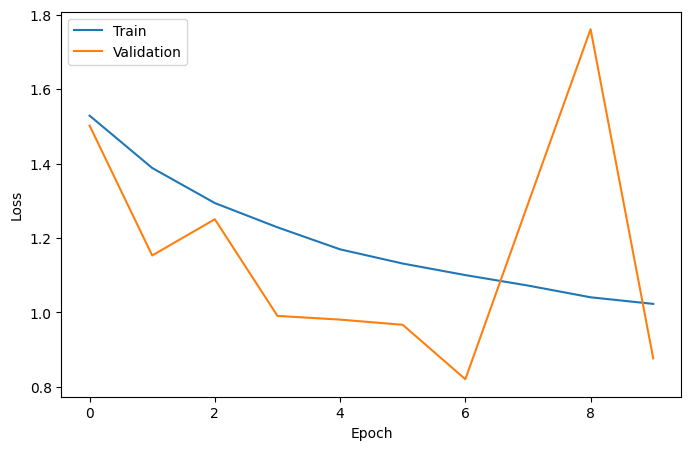

In [ ]:
#Plot loss
plt.figure(figsize=(8,5))

plt.plot(

history.history['loss']

)

plt.plot(

history.history['val_loss']

)

plt.legend(

['Train','Validation']

)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.show()

In [ ]:
#Evaluate model
loss,accuracy=model.evaluate(

X_test,

y_test

)

print("Loss :",loss)

print("Accuracy :",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7179 - loss: 0.8201
Loss : 0.820121169090271
Accuracy : 0.7178999781608582


In [ ]:
#Classification Report
y_pred=model.predict(X_test)

y_pred=np.argmax(

y_pred,

axis=1

)


print(

classification_report(

y_test,

y_pred,

target_names=classes

)

)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
              precision    recall  f1-score   support

    airplane       0.70      0.81      0.75      1000
  automobile       0.84      0.85      0.85      1000
        bird       0.64      0.53      0.58      1000
         cat       0.57      0.45      0.50      1000
        deer       0.73      0.58      0.65      1000
         dog       0.66      0.58      0.62      1000
        frog       0.66      0.87      0.75      1000
       horse       0.69      0.84      0.76      1000
        ship       0.83      0.85      0.84      1000
       truck       0.83      0.81      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



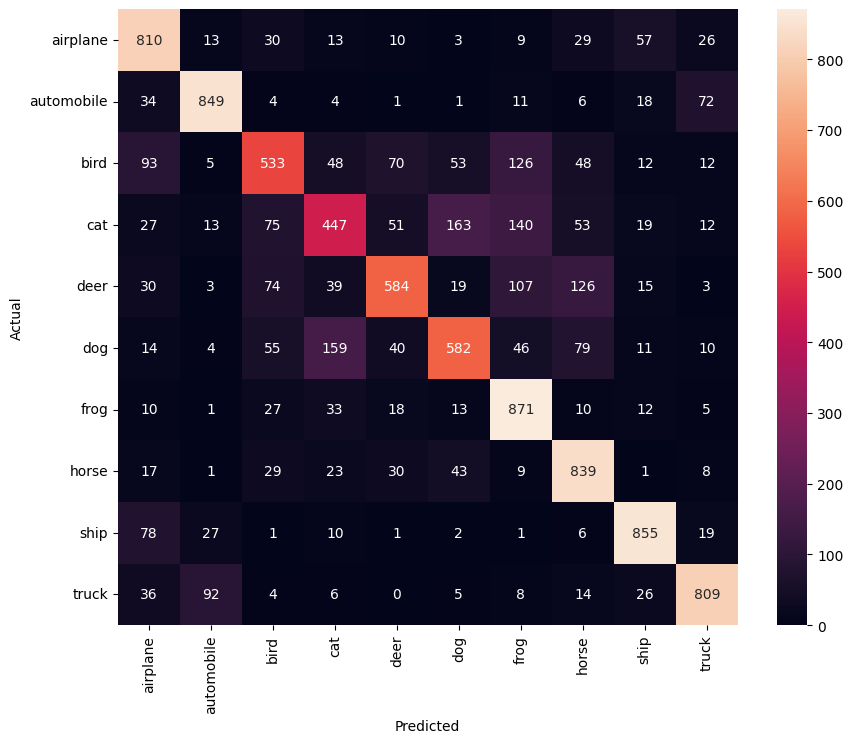

In [ ]:
#Confusion Matrix
cm=confusion_matrix(

y_test,

y_pred

)


plt.figure(

figsize=(10,8)

)

sns.heatmap(

cm,

annot=True,

fmt='d',

xticklabels=classes,

yticklabels=classes

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
#Save model
model.save(

'best_cnn_model.keras'

)

In [ ]:
#load model
from tensorflow.keras.models import load_model


model=load_model(

'best_cnn_model.keras'

)

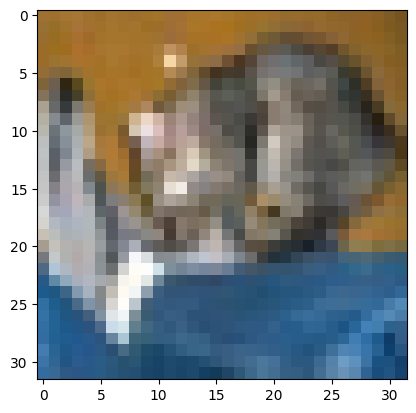

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction : cat


In [ ]:
#predict single image
img=X_test[0]

plt.imshow(img)

plt.show()


pred=model.predict(

np.expand_dims(

img,

axis=0

)

)


pred=np.argmax(pred)

print(

"Prediction :",

classes[pred]

)